In [37]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

CSV_PATH = "golf_shot_data_reversed.csv"

df = pd.read_csv(CSV_PATH)



In [38]:
df.shape[0]

33

In [39]:
df['キャリー (yds)'].max()

106

In [40]:
df['最高到達点 (yds)'].max()

22

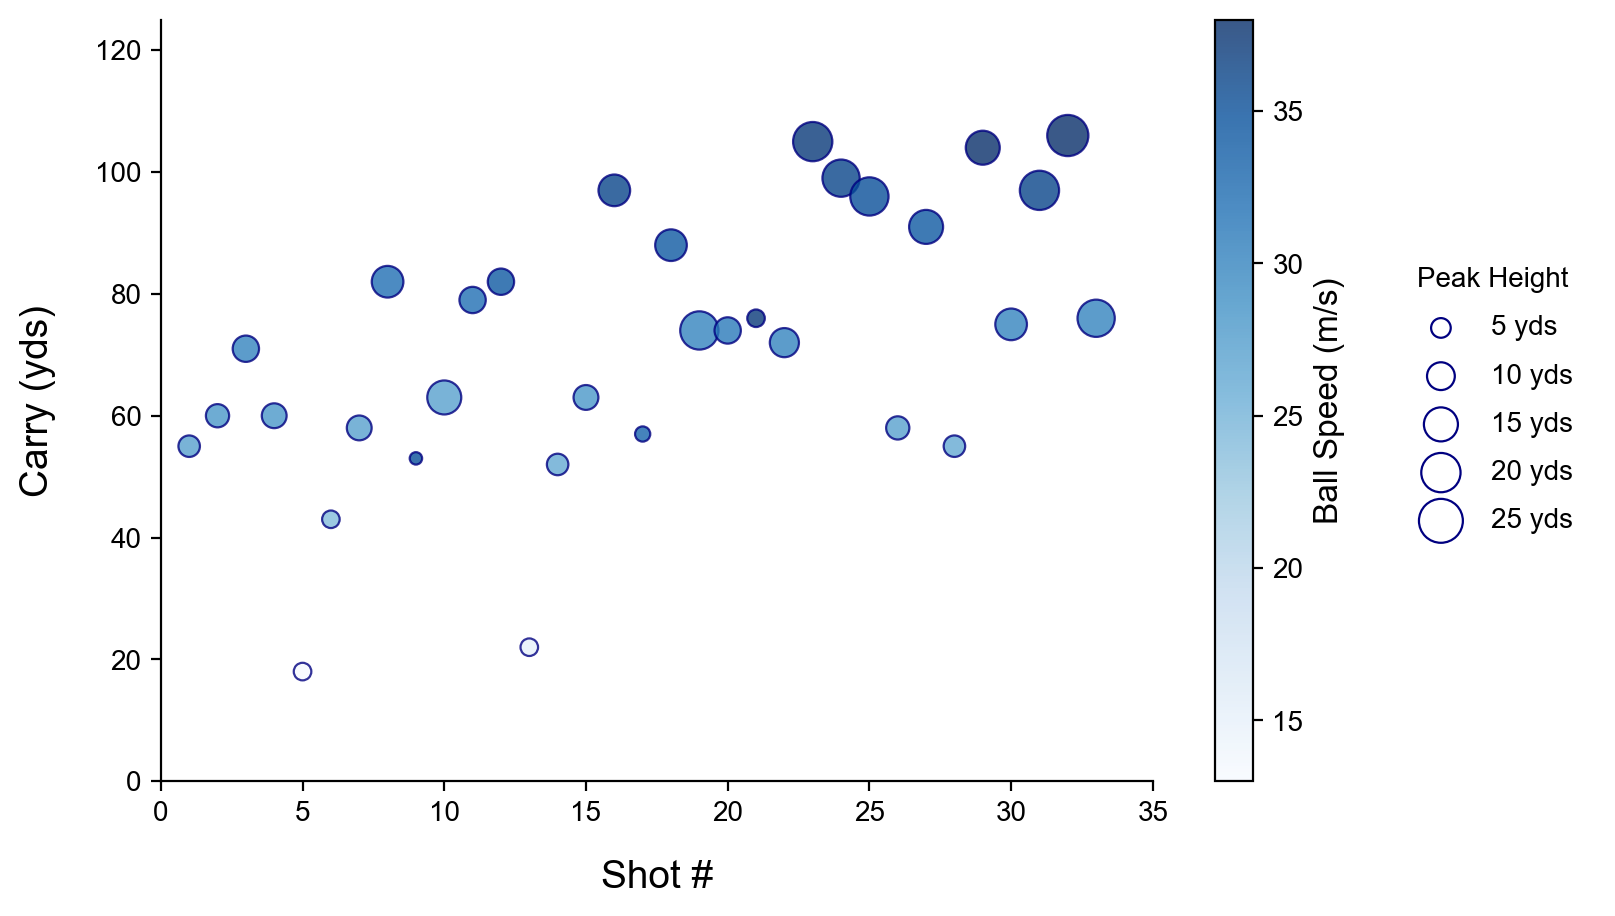

In [41]:
plt.figure(figsize=(8, 8 / 1.618), dpi=200)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = ['Arial']

# 散布図作成
scatter = plt.scatter(
    df['No.'],
    df['キャリー (yds)'],
    c=df['ボールスピード (m/s)'],
    s=df['最高到達点 (yds)'] * 10,
    cmap='Blues',
    alpha=0.8,
    edgecolors='navy',
    linewidths=0.8
)

plt.xlabel('Shot #', labelpad=12, fontsize=14)
plt.ylabel('Carry (yds)', labelpad=14, fontsize=14)
plt.xlim(0, 35)
plt.ylim(0, 125)

# ボールスピードを示すカラーバー
cbar = plt.colorbar(scatter)
cbar.set_label('Ball Speed (m/s)', fontsize=12)

# 円の大きさ（最高到達点）を示す凡例の作成
height_samples = [5, 10, 15, 20, 25]
legend_handles = []
for h in height_samples:
    handle = plt.scatter(
        [], [],
        c='none',
        s=h * 10,
        edgecolors='navy',
        linewidths=0.8,
        label=f'{h} yds'
    )
    legend_handles.append(handle)

plt.legend(
    handles=legend_handles,
    title='Peak Height',
    loc='center left',
    bbox_to_anchor=(1.24, 0.5),
    frameon=False,
    labelspacing=0.8,
    borderpad=0.8,
    borderaxespad=0.0
)

# 画像の保存と表示
plt.savefig('carry_speed_height_scatter_with_legend.png', bbox_inches='tight', dpi=200)
plt.show()


# ALL

In [42]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

CSV_PATH = "golf_shot_data_combined.csv"

df = pd.read_csv(CSV_PATH)



In [43]:
df.columns

Index(['No.', 'キャリー (yds)', 'トータル (yds)', 'ボールスピード (m/s)', '最高到達点 (yds)',
       '打出角 (度)', '左右打出角 (度)', 'キャリーサイド (yds)'],
      dtype='str')

In [44]:
print(df.shape[0])
print(df['キャリー (yds)'].max())
print(df['最高到達点 (yds)'].max())

56
106
22


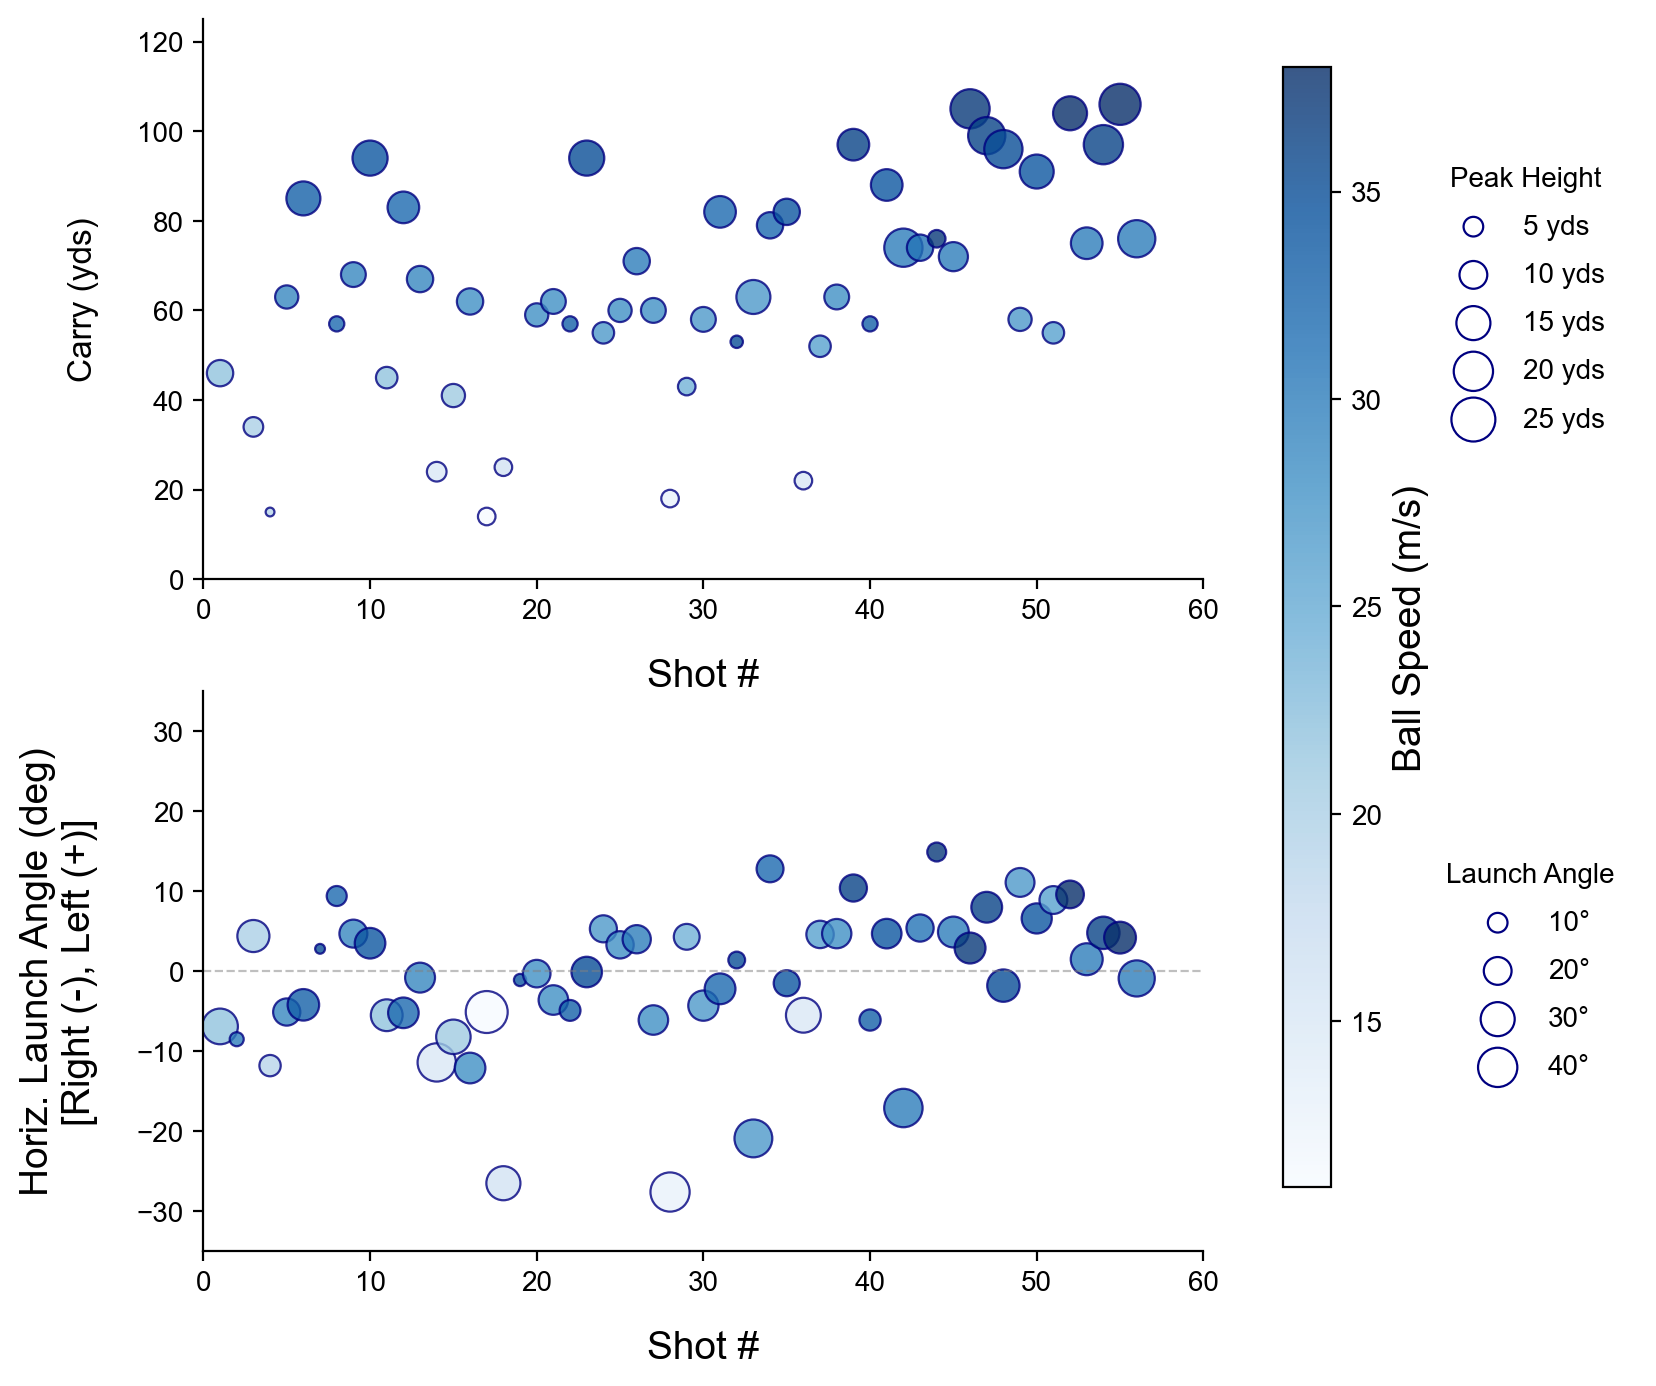

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# CSVの読み込み
df = pd.read_csv("golf_shot_data_combined.csv")

# 1列目に No. を確保
if "No." not in df.columns or df["No."].isnull().any():
    df["No."] = range(1, len(df) + 1)


def parse_left_right_y(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).strip()
    if "右" in val_str:
        return -float(val_str.replace("右", ""))
    elif "左" in val_str:
        return float(val_str.replace("左", ""))
    else:
        return float(val_str)


df["左右打出角_y"] = df["左右打出角 (度)"].apply(parse_left_right_y)
df["打出角_num"] = pd.to_numeric(df["打出角 (度)"], errors="coerce")

# スタイル設定
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = ["Arial"]

# 二段組 figure (X軸位置を同期)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), dpi=200, sharex=True)

# --------------------------------------------------
# 1段目 (ax1)
# --------------------------------------------------
scatter1 = ax1.scatter(
    df["No."],
    df["キャリー (yds)"],
    c=df["ボールスピード (m/s)"],
    s=df["最高到達点 (yds)"] * 10,
    cmap="Blues",
    alpha=0.8,
    edgecolors="navy",
    linewidths=0.8,
)

ax1.set_xlabel("Shot #", labelpad=12, fontsize=14)
ax1.set_ylabel("Carry (yds)", labelpad=14, fontsize=12)
ax1.set_xlim(0, 60)
ax1.set_ylim(0, 125)
ax1.tick_params(labelbottom=True)

# 1段目の凡例（最高到達点）
height_samples = [5, 10, 15, 20, 25]
legend_handles1 = [
    plt.scatter(
        [],
        [],
        c="none",
        s=h * 10,
        edgecolors="navy",
        linewidths=0.8,
        label=f"{h} yds",
    )
    for h in height_samples
]
ax1.legend(
    handles=legend_handles1,
    title="Peak Height",
    loc="center left",
    bbox_to_anchor=(1.22, 0.5),
    frameon=False,
    labelspacing=0.8,
    borderpad=0.8,
    borderaxespad=0.0,
)

# --------------------------------------------------
# 2段目 (ax2): Y軸=左右打出角(左+, 右-), 直径=打出角
# --------------------------------------------------
scatter2 = ax2.scatter(
    df["No."],
    df["左右打出角_y"],
    c=df["ボールスピード (m/s)"],
    s=df["打出角_num"] * 5,  # 打出角の大きさを円のサイズに反映
    cmap="Blues",
    alpha=0.8,
    edgecolors="navy",
    linewidths=0.8,
)

# 左右中央線 (0度)
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

ax2.set_xlabel("Shot #", labelpad=12, fontsize=14)
ax2.set_ylabel(
    "Horiz. Launch Angle (deg)\n[Right (-), Left (+)]", labelpad=14, fontsize=14
)
ax2.set_ylim(-35, 35)

# 2段目の凡例（打出角 / Launch Angle）
launch_angle_samples = [10, 20, 30, 40]
legend_handles2 = [
    plt.scatter(
        [],
        [],
        c="none",
        s=a * 5,
        edgecolors="navy",
        linewidths=0.8,
        label=f"{a}°",
    )
    for a in launch_angle_samples
]
ax2.legend(
    handles=legend_handles2,
    title="Launch Angle",
    loc="center left",
    bbox_to_anchor=(1.22, 0.5),
    frameon=False,
    labelspacing=0.8,
    borderpad=0.8,
    borderaxespad=0.0,
)

# --------------------------------------------------
# 共通カラーバー（ボールスピード）
# --------------------------------------------------
fig.subplots_adjust(right=0.75)
cbar_ax = fig.add_axes([0.80, 0.15, 0.03, 0.7])
cbar = fig.colorbar(scatter1, cax=cbar_ax)
cbar.set_label("Ball Speed (m/s)", fontsize=14)

# 画像保存
plt.savefig("golf_2stage_scatter_corrected.png", bbox_inches="tight", dpi=200)
plt.show()